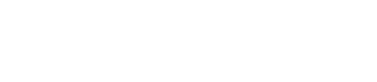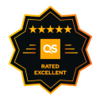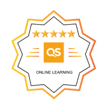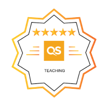

# Machine Learning I · Sesión 3 · Preparación: faltantes, codificación, escalamiento, ingeniería de atributos

**Universidad EAN · Facultad de Ingeniería · Posgrado**

*Profesor:* Jaime Alberto Ochoa Durán

*Profesor en Inteligencia Artificial · Facultad de Ingeniería*

🔗 [LinkedIn · jaimeochoa-manager](https://www.linkedin.com/in/jaimeochoa-manager/)

## Trazabilidad de la sesión · Session traceability

| Campo | Valor |
|---|---|
| Unidad y código | Machine Learning I · IMVN0004 |
| Programa y modalidad | Especialización en Machine Learning · Maestría en Ciencia de Datos · Maestría en Gerencia en Inteligencia Artificial · Presencial |
| Módulo · Sesión | M1, Fundamentos, metodología y preparación · Sesión 3 de 18 |
| Hilo conductor | Fórmula 1: combustible, segunda etapa, refinar el crudo ya diagnosticado |
| Conjunto de datos | Mismo extracto 2019 de siniestros viales de Bogotá, 32 962 filas (Secretaría Distrital de Movilidad, 2021), reconstruido en este cuaderno |
| Fase CRISP-DM | Preparación de los datos |
| Resultado de aprendizaje | Aplicar imputación, codificación y escalamiento sin que la transformación toque el conjunto de prueba |
| Evidencia | Reto acumulativo R3 |
| Nivel cognitivo | Aplicar |
| Tiempo | 50 min de ejecución guiada · Reto R3: 2,25 h autónomas |
| Lenguaje y versión | Python 3.11 · pandas, numpy, scikit-learn |


## Cómo se trabaja este cuaderno · How to work this notebook

1. Responda cada 🎯 y cada 🔮 **antes** de abrir la solución plegada. Abrirla primero convierte el ejercicio en lectura, no en práctica.
2. Ejecute las celdas en orden. Varias secciones dependen del estado que deja la anterior.
3. Si algo genera un error que el enunciado no anticipó, revise primero el orden de ejecución de las celdas antes de reportarlo: es la causa más frecuente.

## Estructura del cuaderno · Notebook structure

| # | Sección | Marca dominante |
|---|---|---|
| 1 | Recuperar el extracto y particionar antes de transformar | 🔮 Predice antes de ejecutar |
| 2 | Imputar los faltantes de PK_CALZADA, CIV y LOCALIDAD | 🩺 Depuración guiada |
| 3 | Codificar variables categóricas sin mezclar columnas entre particiones | 🕵️ Error silencioso 1 |
| 4 | Construir atributos nuevos desde FECHA_HORA_ACC | 🌐 Exercise in English |
| 5 | Escalar las columnas continuas sin fuga | 🕵️ Error silencioso 2 |
| 6 | Síntesis: verificar el conjunto preparado y cerrar con el Reto R3 | 💼 Reto de Negocio de cierre |


## Marcas del cuaderno · Notebook marks

| Marca | Significado |
|---|---|
| 🔁 Repaso | Tres preguntas de la sección anterior |
| 🌱 Analogía | Explicación desde el mundo físico o administrativo, con su límite declarado |
| 🔬 Nota técnica | Profundidad adicional para quien ya programa |
| ⚠️ Error frecuente | El error ruidoso, el que Python reporta |
| 🕵️ Error silencioso | Código que no falla y produce un resultado plausible y falso |
| 🔮 Predice antes de ejecutar | Anticipar el resultado antes de correr la celda |
| 🎯 Ejercicio rápido | Pregunta de discriminación, sin código |
| 🧪 Autocomprobación | Código con verificador sellado |
| 🩺 Depuración guiada | Corregir un error provocado, bajo una restricción |
| 🌐 Exercise in English | Enunciado y respuesta íntegramente en inglés |
| 🛠️ Retos técnicos | Tres niveles: 🟢 guiado, 🟡 aplicado, 🔴 autónomo |
| 💼 Reto de Negocio | Decisión profesional sin código, cinco puntos |
| ✍️ Interpretación | Celda editable para responder el reto de negocio |
| 📚 Referencias | Fuentes APA 7 de la sección |


## Antes de empezar, sus datos · Before you start, your data

Este cuaderno no trae los datos incrustados en el código: vienen aparte, en `ML1_S03_laboratorio_practico_v1.zip`, la carpeta de esta sesión.

1. Descomprima `ML1_S03_laboratorio_practico_v1.zip`. Va a encontrar este cuaderno y el archivo `historico_siniestros_bogota.csv`, el conjunto completo tal como la docencia lo descargó y verificó el 2026-09-20, el mismo archivo crudo que usaron las Sesiones 1 y 2.
2. Suba la carpeta descomprimida a su Google Drive, en cualquier ubicación. El cuaderno busca el archivo por su nombre exacto: lo único que no debe cambiar es el nombre `historico_siniestros_bogota.csv`.
3. Antes de correr la celda de preparación del entorno, intente primero la descarga directa desde el portal oficial: la celda ya lo hace por usted, y solo si esa descarga falla monta su Google Drive y busca el archivo que subió.

## Preparación del entorno · Environment setup

La celda intenta primero descargar el conjunto completo directamente desde el portal oficial. Si esa descarga falla, monta Google Drive y lee el archivo que la docencia ya descargó y verificó. Ninguno de los dos caminos filtra ni transforma nada todavía: el recorte a 2019 y la preparación son contenido visible de este cuaderno.

In [ ]:
import glob
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

SEMILLA = 2026
np.random.seed(SEMILLA)

URL_FUENTE = (
    "https://datosabiertos.bogota.gov.co/dataset/8624f916-1db2-4c17-b669-19a19b35d1ca/"
    "resource/f5862aaa-4e1c-463e-94d5-f04db8164360/download/"
    "historico_siniestros_bogota_d.c_-.csv"
)
NOMBRE_ARCHIVO_RESPALDO = "historico_siniestros_bogota.csv"
FECHA_VERIFICACION_DOCENCIA = "2026-09-20"

try:
    crashes_full = pd.read_csv(URL_FUENTE)
    print(f"Descarga directa desde la fuente oficial: {len(crashes_full)} filas.")
except Exception as e:
    print(f"Descarga directa no disponible ({type(e).__name__}).")
    from google.colab import drive
    drive.mount("/content/drive")

    _coincidencias = glob.glob(
        f"/content/drive/MyDrive/**/{NOMBRE_ARCHIVO_RESPALDO}", recursive=True
    )
    if not _coincidencias:
        raise FileNotFoundError(
            f"No se encontro '{NOMBRE_ARCHIVO_RESPALDO}' en su Google Drive. "
            "Verifique que subio la carpeta descomprimida de "
            "ML1_S03_laboratorio_practico_v1.zip a su Drive, en cualquier ubicacion."
        )
    RUTA_DRIVE = _coincidencias[0]
    print(f"Archivo encontrado en: {RUTA_DRIVE}")
    crashes_full = pd.read_csv(RUTA_DRIVE)
    print(
        f"Se usa el archivo verificado por la docencia el {FECHA_VERIFICACION_DOCENCIA}: "
        f"{len(crashes_full)} filas."
    )

## 1. Recuperar el extracto y particionar antes de transformar · Recovering the extract and splitting before transforming

**Al terminar esta sección podrás:**
1. Reconstruir, en una celda visible, el mismo extracto de datos que usaron las sesiones anteriores.
2. Partir un conjunto en entrenamiento y prueba de forma estratificada.
3. Anticipar si una partición estratificada conserva las proporciones de la variable objetivo.
4. **Juzgar** por qué esta partición debe ocurrir antes de cualquier imputación, codificación o escalamiento, y no después.


Preparar los datos no es aplicar la transformación técnicamente correcta, es aplicarla sin que su ajuste toque, ni siquiera de forma indirecta, la porción de datos que después va a medir el resultado. Esta primera sección no transforma nada todavía: solo aparta el conjunto de prueba, antes de que exista la tentación de tocarlo.

### 1.1 Recuperar el extracto de 2019

Cada sesión de este módulo reconstruye el mismo recorte a 2019 dentro de su propio cuaderno, a partir del mismo archivo crudo completo, sin depender de ningún archivo intermedio que otra sesión haya dejado. No es redundancia: es la garantía de que cualquier persona del equipo, abriendo solo el `.zip` de esta sesión, llega exactamente al mismo punto de partida que las Sesiones 1 y 2 ya verificaron.

In [ ]:
print("Filas totales, 2015 a 2021:", crashes_full.shape[0])
crashes = crashes_full[crashes_full["ANO_OCURRENCIA_ACC"] == 2019].copy()
print("Filas del extracto 2019:", len(crashes))

### 1.2 Particionar antes de transformar

El Reto R2 de la Sesión 2 diagnosticó la calidad del extracto completo: identificadores, faltantes, duplicados, redundancia, desbalance. Esta sesión actúa sobre ese diagnóstico, pero antes de tocar una sola columna hace falta resolver una pregunta de orden que determina si todo lo que sigue es honesto o está contaminado.

Toda transformación que se ajusta a los datos, calcular una media para imputar, aprender las categorías de un codificador, calcular la media y la desviación de un escalador, aprende un número a partir de las filas que observa. Formalmente, dado un conjunto $D$ dividido en entrenamiento $D_{tr}$ y prueba $D_{te}$, toda transformación $T$ con parámetros ajustables $\theta$ debe estimar $\theta$ únicamente a partir de $D_{tr}$:

$$\theta = \text{ajustar}(T, D_{tr})$$

**En palabras:** el número que la transformación aprende no puede haber visto, ni de reojo, ninguna fila del conjunto de prueba. Si ese número se calculó sobre todo el conjunto, entrenamiento y prueba juntos, el conjunto de prueba deja de representar datos genuinamente nuevos: ya influyó, aunque sea mínimamente, en cómo el pipeline transforma los datos, y la medición final de desempeño queda optimista sin que nadie lo note. Por eso la partición ocurre primero, antes de imputar, codificar o escalar, y por eso conviene hacerla estratificada por `GRAVEDAD`: sin estratificar, una partición aleatoria podría, por azar, dejar la clase `CON MUERTOS` sobrerrepresentada en un conjunto y subrepresentada en el otro, distorsionando cualquier comparación posterior.

In [ ]:
train, test = train_test_split(
    crashes, test_size=0.2, random_state=SEMILLA, stratify=crashes["GRAVEDAD"]
)
print("Filas de entrenamiento:", train.shape[0])
print("Filas de prueba:", test.shape[0])

#### 🌱 Analogía · El combustible ya diagnosticado entra a refinería

La Sesión 2 tomó una muestra del crudo y lo analizó en laboratorio, sin refinarlo. Esta sesión mueve el crudo a la refinería, pero primero separa una porción que no va a pasar por el proceso de refinación: esa porción es el conjunto de prueba, que debe llegar al final del proceso tan parecido al crudo original como sea posible, para que sirva como control independiente.

### 🔮 Predice antes de ejecutar 1

Sin ejecutar la siguiente celda: ¿la proporción de la categoría `CON MUERTOS` en `train` va a ser prácticamente igual a la proporción en `test`, o van a diferir de forma notoria? Responda antes de correr la celda.

In [ ]:
print("Proporciones en train:")
print(train["GRAVEDAD"].value_counts(normalize=True))
print("\nProporciones en test:")
print(test["GRAVEDAD"].value_counts(normalize=True))

<details><summary>Ver la explicación</summary>

Van a ser prácticamente iguales, porque `stratify=crashes["GRAVEDAD"]` le pide a `train_test_split` que reparta cada categoría de `GRAVEDAD` en la misma proporción entre entrenamiento y prueba. Sin ese argumento, una categoría tan rara como `CON MUERTOS`, apenas 1,50 % del extracto, podría quedar sobrerrepresentada o subrepresentada en alguno de los dos conjuntos solo por azar.
</details>

### 🎯 Ejercicio rápido 1

¿Por qué la partición de esta sección se hace antes de imputar `PK_CALZADA`, y no después de imputarla?

<details><summary>Ver la solución</summary>

Porque la imputación va a calcular un estadístico, típicamente la mediana para una columna continua, a partir de los datos disponibles en ese momento. Si ese estadístico se calcula antes de partir, sobre las 32 962 filas juntas, incluye información de filas que después van a terminar en el conjunto de prueba, y esa información se filtra hacia el entrenamiento en el momento de imputar: el valor con el que se rellenan los faltantes de `train` ya conoció, aunque sea parcialmente, la distribución de `test`.

El efecto puede parecer insignificante para una sola columna y una sola mediana, pero la lógica se repite y se acumula con cada transformación ajustada a datos que se aplique después, la codificación, el escalamiento, y eventualmente el propio modelo. Particionar primero es la única forma de garantizar que, en cada paso posterior, `test` se comporte como lo que se supone que es: datos que el proceso de preparación nunca vio.
</details>

### 🧪 Autocomprobación 1

Calcule en `resultado` el número exacto de filas del conjunto `test`.

In [ ]:
resultado = int(test.shape[0])

# --- No modifiques nada por debajo de esta línea ----------------------
_ref = int(test.shape[0])
if resultado is None:
    print("\u274c Todavia no completaste la variable.")
elif resultado != _ref:
    print(f"\u274c Tu resultado es {resultado} y deberia ser {_ref}. Revisa que estes contando filas de test, no de train.")
else:
    print(f"\u2705 Correcto. El conjunto de prueba tiene {_ref} filas.")

### 🛠️ Retos técnicos 1

🟢 **Nivel 1, guiado.** Calcule `train.shape[0] + test.shape[0]` y compárelo con `crashes.shape[0]`.

*Criterio de logro:* las dos cifras son iguales, 32 962.

In [ ]:
print(train.shape[0] + test.shape[0], crashes.shape[0])



🟡 **Nivel 2, aplicado.** Verifique que ningún índice de fila aparece a la vez en `train` y en `test`, usando `set(train.index) & set(test.index)`.

*Criterio de logro:* el resultado es un conjunto vacío.

In [ ]:
print(set(train.index) & set(test.index))



🔴 **Nivel 3, autónomo.** Decida qué pasaría con la proporción de `CON MUERTOS` en `test` si se hubiera partido el conjunto sin `stratify`, usando una semilla distinta en cada intento. Nombre por qué esa variabilidad es un riesgo para evaluar un modelo.

*Criterio de logro:* la respuesta nombra explícitamente que sin estratificar, la proporción de una categoría rara puede variar de una partición a otra por puro azar.

📚 Recurso de profundización: Géron, A. (2022). *Hands-on machine learning with Scikit-Learn, Keras, and TensorFlow* (3.ª ed.). O'Reilly Media, capítulo 2.

In [ ]:
# Sin estratificación, la proporción de CON MUERTOS (~1,5 %) en test variaría por azar.
# Esa variación haría inestable la evaluación de una clase poco frecuente.



### 💼 Reto de Negocio 1

Un(a) integrante del equipo propone particionar el conjunto solo cuando llegue el momento de entrenar un modelo, en la Sesión 5, para «no complicar» la preparación de datos de ahora.

**Decisión principal.** ¿Se pospone la partición hasta la Sesión 5, o se hace ya, antes de imputar, codificar o escalar nada?

**Quién resulta perjudicado.** Si se pospone, cualquier estadístico calculado ahora para imputar o escalar ya incorporó información del futuro conjunto de prueba, y quien confíe en la evaluación de la Sesión 5 recibirá un resultado optimista sin saberlo. Si se hace ya, el equipo debe recordar aplicar cada transformación a ambos conjuntos por separado, un poco más de disciplina de código.

**Indicador y por qué no el obvio.** El indicador obvio es «funciona sin errores». El necesario es que ningún estadístico usado para transformar los datos se haya calculado con filas que terminan en el conjunto de prueba.

**Objeción externa.** Alguien podría decir que particionar antes de saber qué modelo se va a usar es prematuro. La respuesta: la partición no depende del modelo, depende de qué filas se van a usar para ajustar cualquier transformación futura, se sepa ya o no el algoritmo.

**Límite del análisis.** Esta partición es válida para evaluar con honestidad un modelo entrenado sobre este extracto; no dice nada sobre cómo se comportaría ese modelo sobre siniestros de un año distinto.

Fase de CRISP-DM: preparación de los datos, donde el orden de las operaciones importa tanto como la operación misma (Chapman et al., 2000).

### ✍️ Celda de interpretación · Reto de Negocio 1

*(Doble clic para editar.)*

**Mi decisión:** Particionaré ahora, antes de ajustar imputadores y escaladores.

**Quién queda perjudicado si me equivoco:** Quienes usen la evaluación recibirían una exactitud sesgada si test participa en la preparación.

**Indicador que usaría y por qué no el obvio:** Verificaría que todos los fit ocurran en train; ejecutar sin error no demuestra ausencia de fuga.

**Cómo respondo a la objeción:** La partición define qué observaciones pueden influir en parámetros, independientemente del algoritmo.

**Qué no puedo saber con esta partición:** Un test aleatorio de 2019 no prueba transferencia a otro año.

### 📚 Referencias de la sección 1

Chapman, P., Clinton, J., Kerber, R., Khabaza, T., Reinartz, T., Shearer, C., y Wirth, R. (2000). *CRISP-DM 1.0: Step-by-step data mining guide*. SPSS Inc.

Géron, A. (2022). *Hands-on machine learning with Scikit-Learn, Keras, and TensorFlow* (3.ª ed.). O'Reilly Media.

Secretaría Distrital de Movilidad. (2021). *Historico Siniestros Bogotá D.C* [Conjunto de datos]. Datos Abiertos Bogotá. Recuperado el 20 de septiembre de 2026, de https://datosabiertos.bogota.gov.co/dataset/historico-siniestros-bogota-d-c

## 2. Imputar los faltantes de PK_CALZADA, CIV y LOCALIDAD · Imputing missing values

**Al terminar esta sección podrás:**
1. Elegir una estrategia de imputación distinta para una columna continua y para una columna categórica.
2. Ajustar un imputador solo sobre el conjunto de entrenamiento y aplicarlo a ambos conjuntos.
3. Reconocer por qué una estrategia de imputación numérica no aplica a una columna de texto.
4. **Diseñar** un criterio propio para decidir entre imputar por mediana o por moda según el tipo de columna.


### 🔁 Repaso

1. ¿Por qué se particiona el conjunto antes de imputar, codificar o escalar?
2. ¿Qué asegura el argumento `stratify` en `train_test_split`?
3. ¿Cuántas filas tiene el conjunto de entrenamiento de esta sesión?

<details><summary>Ver las respuestas</summary>

1. Porque cualquier transformación ajustada a datos que incluya filas del conjunto de prueba filtra información de ese conjunto hacia el entrenamiento.
2. Que cada categoría de la variable indicada, `GRAVEDAD` en este caso, se reparta en la misma proporción entre entrenamiento y prueba.
3. 26 369 filas.
</details>

### 2.1 Imputación de columnas continuas: PK_CALZADA y CIV

**Imputar** es reemplazar un valor faltante por una estimación razonable, para que la columna quede completa sin descartar la fila entera. Para una variable continua, la estrategia más simple es reemplazar cada faltante por un estadístico central de la propia columna. Entre la media y la mediana, la mediana es la elección más robusta cuando la distribución tiene asimetría o valores atípicos, exactamente lo que la Sesión 2 encontró en `PK_CALZADA`: la media se deja arrastrar por los valores extremos, mientras que la mediana, al ser el valor central, apenas se mueve.

El diagnóstico de la Sesión 2 encontró 19,94 % de faltantes en `PK_CALZADA` y 0,27 % en `CIV`, ambas continuas. La mediana que se va a usar, siguiendo la regla de la sección 1.2, se calcula solo sobre `train`, nunca sobre el extracto completo.

In [ ]:
imputador_pk = SimpleImputer(strategy="median")
train["PK_CALZADA"] = imputador_pk.fit_transform(train[["PK_CALZADA"]])
test["PK_CALZADA"] = imputador_pk.transform(test[["PK_CALZADA"]])

imputador_civ = SimpleImputer(strategy="median")
train["CIV"] = imputador_civ.fit_transform(train[["CIV"]])
test["CIV"] = imputador_civ.transform(test[["CIV"]])

print("Mediana de PK_CALZADA aprendida en train:", imputador_pk.statistics_[0])
print("Faltantes de PK_CALZADA tras imputar, train:", train["PK_CALZADA"].isna().sum())
print("Faltantes de PK_CALZADA tras imputar, test:", test["PK_CALZADA"].isna().sum())

`imputador_pk.fit_transform(train[...])` aprende la mediana únicamente de `train`. `imputador_pk.transform(test[...])` aplica esa misma mediana a `test`, sin volver a calcular nada: es la diferencia entre `fit_transform` y `transform` que sostiene toda la sección 1.2.

### 2.2 Imputación de una columna categórica: LOCALIDAD

Una columna categórica no admite mediana: no hay un punto medio entre `KENNEDY` y `SUBA`, del mismo modo que la Sesión 1 ya mostró que `GRAVEDAD` no admite un promedio sin inventar un orden arbitrario. Cuando la variable es nominal, la estrategia de imputación equivalente es la **moda**: la categoría más frecuente reemplaza al faltante, bajo el supuesto de que, sin más información, la categoría más común es la estimación individual con menor error esperado.

`LOCALIDAD` tiene solo 2 faltantes en `train`, dispersos, sin patrón notorio: un caso casi de manual para la moda, muy distinto del 19,94 % concentrado de `PK_CALZADA`.

### 🩺 Depuración guiada 1

Un(a) compañero(a), acostumbrado(a) a `PK_CALZADA` y `CIV`, escribe la misma celda para `LOCALIDAD`:

In [ ]:
imputador_localidad = SimpleImputer(strategy="mean")
train["LOCALIDAD"] = imputador_localidad.fit_transform(train[["LOCALIDAD"]])

**Restricción para corregirla:** sin convertir `LOCALIDAD` a números arbitrarios. La columna es nominal, sin orden, así que ninguna conversión numérica previa es defendible antes de imputar.

<details><summary>Ver la corrección</summary>

```python
imputador_localidad = SimpleImputer(strategy="most_frequent")
train["LOCALIDAD"] = imputador_localidad.fit_transform(train[["LOCALIDAD"]]).ravel()
test["LOCALIDAD"] = imputador_localidad.transform(test[["LOCALIDAD"]]).ravel()
```

La estrategia `"mean"` exige calcular un promedio, una operación que no está definida sobre texto: Python lanza `ValueError`. La estrategia `"most_frequent"` calcula la moda, la única operación de tendencia central que tiene sentido sobre una columna categórica, y sigue ajustándose solo sobre `train`.
</details>

In [ ]:
imputador_localidad = SimpleImputer(strategy="most_frequent")
train["LOCALIDAD"] = imputador_localidad.fit_transform(train[["LOCALIDAD"]]).ravel()
test["LOCALIDAD"] = imputador_localidad.transform(test[["LOCALIDAD"]]).ravel()
print("Moda de LOCALIDAD aprendida en train:", imputador_localidad.statistics_[0])
print("Faltantes de LOCALIDAD tras imputar, train:", train["LOCALIDAD"].isna().sum())

### 🎯 Ejercicio rápido 2

¿Por qué `test["PK_CALZADA"]` se transforma con `imputador_pk.transform(...)` y no con `imputador_pk.fit_transform(...)`?

<details><summary>Ver la solución</summary>

Porque `fit_transform` volvería a calcular la mediana, esta vez sobre `test`, lo que produciría un valor de imputación distinto al aprendido en entrenamiento y, peor aún, estaría usando información del propio conjunto de prueba para transformarlo, la misma fuga que la partición de la sección 1 buscaba evitar. `transform`, en cambio, no recalcula nada: aplica sobre `test` exactamente el mismo número que `imputador_pk` ya aprendió de `train`, así que `test` recibe el mismo tratamiento que recibiría cualquier dato genuinamente nuevo el día que el modelo esté en producción.

La distinción entre `fit_transform` y `transform` es, en el fondo, la misma distinción entre aprender y aplicar. Un objeto de `scikit-learn` como `SimpleImputer` solo debe aprender una vez, sobre los datos de entrenamiento, y esa regla vale exactamente igual para el imputador, el codificador y el escalador que vienen en las siguientes secciones: `fit` una sola vez sobre `train`, `transform` cuantas veces haga falta.
</details>

### 🧪 Autocomprobación 2

Calcule en `resultado` la mediana de `PK_CALZADA` aprendida por `imputador_pk`, consultando `imputador_pk.statistics_[0]`.

In [ ]:
resultado = float(imputador_pk.statistics_[0])

# --- No modifiques nada por debajo de esta línea ----------------------
_ref = float(imputador_pk.statistics_[0])
if resultado is None:
    print("\u274c Todavia no completaste la variable.")
elif abs(resultado - _ref) > 1e-6:
    print(f"\u274c Tu resultado es {resultado} y deberia ser {_ref}. Revisa que consultes imputador_pk.statistics_[0].")
else:
    print(f"\u2705 Correcto. La mediana aprendida es {_ref}.")

### 🛠️ Retos técnicos 2

🟢 **Nivel 1, guiado.** Calcule cuántos faltantes quedan en `test["CIV"]` después de aplicar `imputador_civ.transform(...)`.

*Criterio de logro:* el resultado es 0.

In [ ]:
civ_test = imputador_civ.transform(test[['CIV']])
print(np.isnan(civ_test).sum())



🟡 **Nivel 2, aplicado.** Calcule la moda de `LOCALIDAD` en `test` por separado, y compárela con la moda aprendida en `train`.

*Criterio de logro:* el resultado reporta ambas modas, aunque sean iguales.

In [ ]:
moda_test = crashes.loc[test.index, 'LOCALIDAD'].mode()[0]
print('Moda original de test:', moda_test)
print('Moda aprendida en train:', imputador_localidad.statistics_[0])



🔴 **Nivel 3, autónomo.** Decida si imputar `PK_CALZADA` con la mediana sigue siendo defendible sabiendo que 16,06 % de sus valores no nulos son atípicos según el rango intercuartílico, diagnóstico de la Sesión 2. Nombre una alternativa y su desventaja.

*Criterio de logro:* la respuesta nombra al menos una alternativa, por ejemplo imputar por grupo de localidad, y una desventaja concreta de esa alternativa.

📚 Recurso de profundización: Little, R. J. A., y Rubin, D. B. (2019). *Statistical analysis with missing data* (3.ª ed.). Wiley.

In [ ]:
# La mediana de train es resistente a atípicos, por eso sigue siendo defendible.
# Una alternativa es imputar por localidad, pero los grupos pequeños producen estimaciones inestables.



### 💼 Reto de Negocio 2

El área de infraestructura vial de la Secretaría pide imputar `PK_CALZADA` con el valor 0 en vez de la mediana, «para no inventar un número que no midieron».

**Decisión principal.** ¿Se acepta imputar con 0, o se mantiene la mediana calculada sobre `train`?

**Quién resulta perjudicado.** Imputar con 0 introduce un valor extremo, fuera del rango real de `PK_CALZADA`, en 19,94 % de las filas, lo que puede distorsionar cualquier estadístico o modelo futuro que use esa columna. Mantener la mediana no «inventa» un valor real tampoco, pero al menos no distorsiona la escala de la variable.

**Indicador y por qué no el obvio.** El indicador obvio es «0 significa que no se midió, es honesto». El necesario es el efecto de ese valor sobre la distribución de la columna y sobre cualquier modelo que la use.

**Objeción externa.** El área de infraestructura podría insistir en que un valor inventado es peor que un cero explícito. La respuesta: ambas son convenciones artificiales; la pregunta relevante es cuál distorsiona menos la distribución real de la variable, y 0 está muy por debajo del rango típico de `PK_CALZADA`.

**Límite del análisis.** Ninguna estrategia de imputación recupera la información que realmente faltaba: ambas son aproximaciones declaradas, no mediciones reales.

Fase de CRISP-DM: preparación de los datos, donde cada decisión de imputación debe poder justificarse ante quien usa el dato después (Chapman et al., 2000).

### ✍️ Celda de interpretación · Reto de Negocio 2

*(Doble clic para editar.)*

**Mi decisión:** Mantendré la mediana aprendida en train para PK_CALZADA.

**Quién queda perjudicado si me equivoco:** El modelo podría aprender un cero artificial en cerca de una quinta parte de los registros.

**Indicador que usaría y por qué no el obvio:** Compararía distribuciones y desempeño de imputaciones dentro de validación, no tomaría cero como sinónimo de ausencia.

**Cómo respondo a la objeción:** Cero también es un valor inventado y puede quedar fuera del rango típico.

**Qué no puedo saber con esta imputación:** No conozco el valor real de las filas incompletas.

### 📚 Referencias de la sección 2

Chapman, P., Clinton, J., Kerber, R., Khabaza, T., Reinartz, T., Shearer, C., y Wirth, R. (2000). *CRISP-DM 1.0: Step-by-step data mining guide*. SPSS Inc.

Little, R. J. A., y Rubin, D. B. (2019). *Statistical analysis with missing data* (3.ª ed.). Wiley.

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., y Duchesnay, É. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research, 12*, 2825-2830.

## 3. Codificar variables categóricas sin mezclar columnas entre particiones · Encoding without mixing columns across splits

**Al terminar esta sección podrás:**
1. Codificar una variable nominal con codificación one-hot.
2. Ajustar el codificador solo sobre `train` y aplicarlo a `test`.
3. Explicar por qué codificar cada partición por separado, sin ajustar un único codificador, puede producir columnas distintas entre `train` y `test`.
4. **Diseñar** una verificación que confirme que ambas particiones codificadas tienen las mismas columnas, en el mismo orden.


### 🔁 Repaso

1. ¿Con qué estrategia se imputó `LOCALIDAD`, y por qué no con la media?
2. ¿Qué diferencia hay entre `fit_transform` y `transform` en un imputador ya ajustado?
3. ¿Cuántos faltantes le quedan a `PK_CALZADA` en `train` después de imputar?

<details><summary>Ver las respuestas</summary>

1. Con la moda (`most_frequent`), porque la media no está definida sobre texto.
2. `fit_transform` aprende el estadístico y lo aplica; `transform` solo aplica el estadístico ya aprendido, sin recalcularlo.
3. Cero.
</details>

### 3.1 Codificación one-hot de LOCALIDAD y CLASE_ACC

Ningún algoritmo de `scikit-learn` opera directamente sobre texto: todo modelo espera números. Convertir una variable categórica a un número exige una decisión, y no cualquier conversión sirve. Asignar un entero arbitrario a cada categoría, `KENNEDY = 1`, `SUBA = 2`, introduciría un orden y una distancia entre localidades que no existen en la realidad: el modelo podría aprender, sin que nadie se lo pidiera, que `SUBA` es «el doble» de algo que `KENNEDY`.

La **codificación one-hot** evita ese problema: representa cada categoría como una columna binaria propia, con 1 si la fila pertenece a esa categoría y 0 en caso contrario. Una variable con $k$ categorías se convierte en $k$ columnas nuevas, ninguna de ellas ordenada respecto a las demás. `LOCALIDAD` y `CLASE_ACC` son nominales, sin orden, así que esta es la codificación que les corresponde. El codificador, igual que el imputador de la sección 2, se ajusta solo sobre `train`: aprende ahí cuáles son las categorías válidas, antes de aplicar esa misma estructura de columnas a `test`.

In [ ]:
columnas_categoricas = ["LOCALIDAD", "CLASE_ACC"]

codificador = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
codificador.fit(train[columnas_categoricas])

print("Categorias de LOCALIDAD aprendidas en train:", len(codificador.categories_[0]))
print("Categorias de CLASE_ACC aprendidas en train:", len(codificador.categories_[1]))

### 🕵️ Error silencioso 1

Una manera habitual de codificar variables categóricas, sin pasar por `scikit-learn`, es `pandas.get_dummies`. Aplicada por separado sobre `train` y sobre `test`, cada llamada solo conoce las categorías presentes en la tabla que recibió:

In [ ]:
dummies_train = pd.get_dummies(train[["LOCALIDAD"]], columns=["LOCALIDAD"])
dummies_test = pd.get_dummies(test[["LOCALIDAD"]], columns=["LOCALIDAD"])

print("Columnas en dummies_train:", dummies_train.shape[1])
print("Columnas en dummies_test:", dummies_test.shape[1])

La celda no falla. `dummies_train` y `dummies_test` simplemente tienen un número distinto de columnas.

<details><summary>🕵️ Qué ocurrió, por qué nadie avisó, y la corrección</summary>

**Qué ocurrió.** `SUMAPAZ`, con solo 2 filas en todo el extracto, quedó por completo dentro de `train` al particionar: `dummies_train` incluye una columna `LOCALIDAD_SUMAPAZ` que `dummies_test` no tiene, porque `get_dummies` solo genera columnas para las categorías que ve en la tabla que recibió, cada vez que se llama.

**Por qué nadie avisó.** `pd.get_dummies` es una función correcta que hace exactamente lo que promete: convertir las categorías presentes en columnas binarias. No es su responsabilidad saber que existe otra tabla, `test`, con la que sus columnas deberían coincidir.

**La corrección.** El `OneHotEncoder` de la sección 3.1 se ajusta una sola vez, sobre `train`, y memoriza el conjunto completo de categorías vistas: al transformar `test`, genera exactamente esas mismas columnas, en el mismo orden, sin importar qué categorías aparecen o no en `test`.
```python
X_train_cat = codificador.transform(train[columnas_categoricas])
X_test_cat = codificador.transform(test[columnas_categoricas])
print(X_train_cat.shape[1] == X_test_cat.shape[1])
```

**Conexión con el otro error silencioso del cuaderno.** El error silencioso 2, en la sección 5, muestra el mismo problema de fondo en el escalamiento: una operación que parece igual de correcta aplicada por separado a cada partición, sin ajustarse una sola vez sobre `train`, produce un resultado distinto sin que nada avise del error.
</details>

In [ ]:
X_train_cat = codificador.transform(train[columnas_categoricas])
X_test_cat = codificador.transform(test[columnas_categoricas])
print("Columnas en X_train_cat:", X_train_cat.shape[1])
print("Columnas en X_test_cat:", X_test_cat.shape[1])
print("Mismas columnas en ambos conjuntos:", X_train_cat.shape[1] == X_test_cat.shape[1])

### 🎯 Ejercicio rápido 3

Si `test` tuviera una localidad que jamás aparece en `train`, ¿qué haría `codificador.transform(test[...])`, dado que se construyó con `handle_unknown="ignore"`?

<details><summary>Ver la solución</summary>

Codificaría esa fila con todas las columnas de `LOCALIDAD` en cero, en vez de lanzar un error. Es el comportamiento contrario, y más seguro en producción, al valor por defecto de `OneHotEncoder`, que lanzaría un error ante una categoría nunca vista en `train`.

La razón de fondo importa más que el comportamiento en sí: un codificador ajustado solo conoce el mundo que vio durante el ajuste. Una categoría nueva es, para el codificador, literalmente indistinguible de «ninguna categoría conocida», así que representarla como un vector de ceros es la forma honesta de decir «esto no encaja en lo que aprendí», en vez de fallar de forma ruidosa cada vez que llega un dato ligeramente distinto de los que se usaron para entrenar. Ese mismo principio, que el conjunto de prueba y, más adelante, los datos de producción pueden traer categorías que el entrenamiento nunca vio, es una constante en todo el pipeline: el codificador no lo previene, lo maneja sin detener el proceso.
</details>

### 🧪 Autocomprobación 3

Calcule en `resultado` cuántas columnas tiene `dummies_train` de más que `dummies_test` (use `dummies_train.shape[1] - dummies_test.shape[1]`).

In [ ]:
resultado = int(dummies_train.shape[1] - dummies_test.shape[1])

# --- No modifiques nada por debajo de esta línea ----------------------
_ref = int(dummies_train.shape[1] - dummies_test.shape[1])
if resultado is None:
    print("\u274c Todavia no completaste la variable.")
elif resultado != _ref:
    print(f"\u274c Tu resultado es {resultado} y deberia ser {_ref}. Revisa el shape de ambos DataFrames.")
else:
    print(f"\u2705 Correcto. dummies_train tiene {_ref} columna(s) de mas.")

### 🛠️ Retos técnicos 3

🟢 **Nivel 1, guiado.** Muestre `codificador.categories_[1]`, las categorías aprendidas de `CLASE_ACC`.

*Criterio de logro:* el resultado lista exactamente 6 categorías.

In [ ]:
print(codificador.categories_[1])



🟡 **Nivel 2, aplicado.** Identifique, con código, cuál columna de `dummies_train.columns` no está en `dummies_test.columns`.

*Criterio de logro:* el resultado es `LOCALIDAD_SUMAPAZ`.

In [ ]:
print(dummies_train.columns.difference(dummies_test.columns).tolist())



🔴 **Nivel 3, autónomo.** Decida si `handle_unknown="ignore"` es una decisión segura en general, o si depende del problema. Nombre una situación donde ignorar una categoría nueva, codificándola en ceros, sería riesgoso.

*Criterio de logro:* la respuesta nombra un escenario donde una categoría nueva representa información importante que un vector de ceros oculta por completo.

📚 Recurso de profundización: Pedregosa, F., et al. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research, 12*, 2825-2830.

In [ ]:
# Depende del problema: una localidad nueva con riesgo alto codificada en ceros podría ocultar
# información relevante. Conviene vigilar categorías no vistas y reentrenar si aparecen.



### 💼 Reto de Negocio 3

Un(a) integrante del equipo, apurado por el tiempo, propone usar `pd.get_dummies` sobre `train` y `test` por separado, «porque es una línea de código menos».

**Decisión principal.** ¿Se acepta el atajo de `get_dummies` por separado, o se exige el `OneHotEncoder` ajustado una sola vez?

**Quién resulta perjudicado.** Si se acepta el atajo, cualquier código posterior que asuma que `train` y `test` codificados tienen las mismas columnas, en el mismo orden, va a fallar o, peor, va a producir un resultado incorrecto sin ningún error visible. Quien reciba ese resultado sin saberlo confía en un número equivocado.

**Indicador y por qué no el obvio.** El indicador obvio es «el código corrió sin errores». El necesario es verificar explícitamente que ambas particiones codificadas tienen el mismo número de columnas, en el mismo orden.

**Objeción externa.** Alguien podría decir que revisar columna por columna es perfeccionismo. La respuesta: esta sesión ya demostró, por ejecución real, que el atajo produce un resultado distinto entre `train` y `test`; no es un riesgo hipotético.

**Límite del análisis.** Esta verificación confirma que las columnas coinciden, no que la codificación sea la estrategia correcta para todos los algoritmos futuros de la unidad.

Fase de CRISP-DM: preparación de los datos, donde una verificación barata evita un error costoso de detectar más adelante (Chapman et al., 2000).

### ✍️ Celda de interpretación · Reto de Negocio 3

*(Doble clic para editar.)*

**Mi decisión:** Usaré OneHotEncoder ajustado en train y aplicado a test.

**Quién queda perjudicado si me equivoco:** Predicciones y reportes pueden quedar desalineados si ambas particiones generan columnas distintas.

**Indicador que usaría y por qué no el obvio:** Comprobaría igual número y orden de columnas; que el código corra no basta.

**Cómo respondo a la objeción:** SUMAPAZ muestra una columna presente en train y ausente en test con get_dummies separado.

**Qué no puedo saber con esta verificación:** La igualdad de dimensiones no demuestra que el codificador sea ideal para todo modelo.

### 📚 Referencias de la sección 3

Chapman, P., Clinton, J., Kerber, R., Khabaza, T., Reinartz, T., Shearer, C., y Wirth, R. (2000). *CRISP-DM 1.0: Step-by-step data mining guide*. SPSS Inc.

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., y Duchesnay, É. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research, 12*, 2825-2830.

Wickham, H. (2014). Tidy data. *Journal of Statistical Software, 59*(10), 1-23.

## 4. Construir atributos nuevos desde FECHA_HORA_ACC · Engineering new attributes

**Al terminar esta sección podrás:**
1. Convertir una columna de texto a un tipo de fecha real.
2. Construir atributos derivados de una fecha, justificados por el fenómeno que describen.
3. Argumentar, en inglés, por qué un atributo derivado del tiempo es razonable para este problema.
4. **Diseñar** un atributo nuevo propio, distinto de los ya construidos, y justificarlo.


### 🔁 Repaso

1. ¿Qué columna codificada mostró un número distinto de categorías entre `train` y `test` al usar `get_dummies`?
2. ¿Por qué `OneHotEncoder` no tuvo ese problema?
3. ¿Qué hace `handle_unknown="ignore"` ante una categoría nunca vista en `train`?

<details><summary>Ver las respuestas</summary>

1. `LOCALIDAD`, por la categoría `SUMAPAZ`.
2. Porque se ajustó una sola vez sobre `train` y memorizó el conjunto completo de categorías, aplicando siempre las mismas columnas a cualquier conjunto nuevo.
3. La codifica en ceros en vez de lanzar un error.
</details>

### 4.1 De texto a fecha

**Ingeniería de atributos** (*feature engineering*) es el proceso de construir nuevas columnas a partir de las que ya existen, cuando esas columnas originales no exponen directamente el patrón que un modelo podría aprovechar. Una fecha completa, como `2019-07-14 23:45:00`, es difícil de usar tal cual: lo que probablemente importa para predecir siniestralidad no es el instante exacto, sino patrones que se repiten, la hora del día, el día de la semana, si es de noche o de madrugada.

Pero antes de poder extraer cualquiera de esos atributos, hace falta que Python sepa que esa cadena de texto es una fecha. `FECHA_HORA_ACC` sigue siendo de tipo `object`, diagnóstico pendiente desde la Sesión 2. Convertirla a un tipo de fecha real, con `pd.to_datetime`, es lo que habilita todo lo que sigue en esta sección: sin esa conversión, pandas trata la columna como texto arbitrario, sin ningún concepto de hora, día de la semana o estación del año.

#### ⚠️ Error frecuente

Intentar extraer la hora sin convertir la columna todavía produce un error ruidoso e inmediato:

In [ ]:
train["FECHA_HORA_ACC"].dt.hour

`AttributeError`: el accesor `.dt` solo existe en columnas ya convertidas a fecha. La conversión, con `pd.to_datetime`, es el primer paso de esta sección.

In [ ]:
train["FECHA_HORA_ACC"] = pd.to_datetime(train["FECHA_HORA_ACC"])
test["FECHA_HORA_ACC"] = pd.to_datetime(test["FECHA_HORA_ACC"])
print(train["FECHA_HORA_ACC"].dtype)

### 4.2 Atributos nuevos: hora, día de la semana y fin de semana

Con `FECHA_HORA_ACC` ya convertida a un tipo de fecha real, se puede extraer cualquier componente que ese tipo expone: el año, el mes, el día, la hora, el día de la semana. Extraer un componente es mecánico, con el accesor `.dt`; justificarlo no lo es. La regla de esta sección, y de la ingeniería de atributos en general, es que cada columna nueva se propone por una razón del fenómeno que describe, no simplemente porque el dato crudo permite calcularla.

Aquí la razón es directa: el volumen de tráfico, la visibilidad y el nivel de fatiga de quien conduce varían de forma sistemática según la hora del día y el día de la semana. Es razonable esperar, antes incluso de ver un solo número, que la hora del siniestro y si ocurrió en fin de semana tengan alguna relación con su gravedad. Esta sección solo construye esos tres atributos; si de verdad ayudan a un modelo es una pregunta que las sesiones de modelado, desde la Sesión 5, responderán con evidencia, no con este argumento razonado por sí solo.

In [ ]:
for df_ in (train, test):
    df_["hora_siniestro"] = df_["FECHA_HORA_ACC"].dt.hour
    df_["dia_semana"] = df_["FECHA_HORA_ACC"].dt.dayofweek
    df_["es_fin_de_semana"] = df_["dia_semana"].isin([5, 6]).astype(int)

print("Proporcion de fin de semana en train:", train["es_fin_de_semana"].mean())
print(train[["hora_siniestro", "dia_semana", "es_fin_de_semana"]].head(3))

### 🌐 Exercise in English 1

**Prompt.** A colleague argues: *«Adding `hora_siniestro` and `dia_semana` is just adding noise. GRAVEDAD depends on the crash, not on the clock.»* Write two short paragraphs in English: one defending this claim, and one arguing against it, using what this notebook already showed about justified feature engineering.

<details><summary>See a model answer</summary>

**For.** Not every possible derived feature improves a model, and adding features without evidence can add noise, make the model harder to interpret, and increase the risk of overfitting to patterns that do not generalize.

**Against.** `hora_siniestro` and `dia_semana` are not arbitrary: traffic volume, visibility, and driver fatigue all vary by time of day and day of week, so it is reasonable to expect some relationship with crash severity. This notebook only justifies proposing the feature, the same way Section 3.5 of the design document requires a reason grounded in the phenomenon; whether the feature actually helps a model is a question the sessions on modeling, starting in Session 5, will answer with evidence, not with an argument from first principles.
</details>

### 🎯 Ejercicio rápido 4

¿Por qué `es_fin_de_semana` se calcula a partir de `dia_semana`, y no directamente de `FECHA_HORA_ACC`?

<details><summary>Ver la solución</summary>

Porque `dia_semana` ya resume, en un solo entero de 0 a 6, exactamente la información de fecha necesaria para decidir si es fin de semana: no hace falta volver a consultar la fecha completa, con hora, minuto y segundo, para responder una pregunta que solo depende del día de la semana. Calcularlo desde `dia_semana` evita repetir la lógica de extracción de fecha en dos lugares distintos del código, y si mañana cambiara la definición de qué cuenta como día de la semana, solo habría que corregirla en un sitio.

Este pequeño detalle ilustra un principio más general de ingeniería de atributos: los atributos nuevos pueden construirse unos sobre otros, formando una pequeña cadena de dependencias, en vez de que cada uno reconstruya desde cero la información que otro ya calculó. `es_fin_de_semana` depende de `dia_semana`, que a su vez depende de `FECHA_HORA_ACC` ya convertida: cada paso reutiliza el trabajo del anterior.
</details>

### 🧪 Autocomprobación 4

Calcule en `resultado` la proporción de siniestros de fin de semana en `train`, redondeada a 4 decimales.

In [ ]:
resultado = round(train['es_fin_de_semana'].mean(), 4)

# --- No modifiques nada por debajo de esta línea ----------------------
_ref = round(train["es_fin_de_semana"].mean(), 4)
if resultado is None:
    print("\u274c Todavia no completaste la variable.")
elif round(resultado, 4) != _ref:
    print(f"\u274c Tu resultado es {resultado} y deberia ser {_ref}. Revisa que promedies es_fin_de_semana sobre train.")
else:
    print(f"\u2705 Correcto. {_ref:.2%} de los siniestros de train ocurren en fin de semana.")

### 🛠️ Retos técnicos 4

🟢 **Nivel 1, guiado.** Calcule cuántos siniestros de `train` ocurrieron entre la medianoche y las 5 de la mañana, usando `hora_siniestro`.

*Criterio de logro:* el resultado es un número entero positivo.

In [ ]:
print(train['hora_siniestro'].between(0, 5).sum())



🟡 **Nivel 2, aplicado.** Construya un atributo `es_hora_pico`, verdadero si `hora_siniestro` está entre 6 y 9 o entre 17 y 20, en ambos conjuntos.

*Criterio de logro:* el atributo existe en `train` y en `test`, con valores 0 o 1.

In [ ]:
for datos in (train, test):
    hora = datos['hora_siniestro']
    datos['es_hora_pico'] = (hora.between(6, 9) | hora.between(17, 20)).astype(int)
print(train['es_hora_pico'].value_counts())
print(test['es_hora_pico'].value_counts())



🔴 **Nivel 3, autónomo.** Proponga, sin código, un atributo nuevo distinto de los ya construidos, a partir de cualquier columna del extracto, y justifique con una razón del fenómeno, no solo porque el dato lo permite calcular.

*Criterio de logro:* la propuesta nombra una columna fuente y una razón del fenómeno de siniestralidad vial que la justifique.

📚 Recurso de profundización: Géron, A. (2022). *Hands-on machine learning with Scikit-Learn, Keras, and TensorFlow* (3.ª ed.). O'Reilly Media, capítulo 2.

In [ ]:
# Agruparía DIRECCION por corredor vial: el tipo de vía podría reflejar exposición
# y condiciones del tránsito, siempre que la ubicación se conozca al predecir.



### 💼 Reto de Negocio 4

La Secretaría pregunta si vale la pena construir diez atributos nuevos más a partir de `FECHA_HORA_ACC` y `DIRECCION`, «mientras más variables, mejor el modelo».

**Decisión principal.** ¿Se construyen los diez atributos adicionales ahora, o se limita la sesión a los ya justificados y se deja la puerta abierta para más adelante?

**Quién resulta perjudicado.** Construir atributos sin una razón del fenómeno detrás puede introducir ruido y hacer el conjunto más difícil de interpretar, sin garantía de mejorar ningún modelo futuro. Limitarse a los ya justificados puede dejar fuera una señal útil que nadie propuso todavía.

**Indicador y por qué no el obvio.** El indicador obvio es «más columnas». El necesario es que cada columna nueva tenga una razón nombrable del fenómeno que describe, la misma regla de la sección 3.5 del diseño de esta sesión.

**Objeción externa.** Alguien podría insistir en que un algoritmo de selección de variables, más adelante en la unidad, va a descartar solo las columnas inútiles. La respuesta: ese argumento pospone el criterio, no lo reemplaza, y agregar variables sin criterio ahora aumenta el trabajo de limpieza después.

**Límite del análisis.** Ningún atributo construido en esta sesión se validó todavía contra el desempeño de un modelo real: esa validación llega desde la Sesión 5.

Fase de CRISP-DM: preparación de los datos, en su actividad de ingeniería de atributos (Chapman et al., 2000).

### ✍️ Celda de interpretación · Reto de Negocio 4

*(Doble clic para editar.)*

**Mi decisión:** Mantendré atributos temporales justificados y evaluaré nuevas ideas en entrenamiento.

**Quién queda perjudicado si me equivoco:** Añadir ruido puede perjudicar la predicción y la interpretación.

**Indicador que usaría y por qué no el obvio:** Evaluaría la contribución de cada atributo en validación; contar columnas no mide utilidad.

**Cómo respondo a la objeción:** La selección automática no sustituye justificar qué describe cada variable ni su disponibilidad al predecir.

**Qué no puedo saber con estos atributos:** Aún no medimos mejora en un modelo.

### 📚 Referencias de la sección 4

Chapman, P., Clinton, J., Kerber, R., Khabaza, T., Reinartz, T., Shearer, C., y Wirth, R. (2000). *CRISP-DM 1.0: Step-by-step data mining guide*. SPSS Inc.

Géron, A. (2022). *Hands-on machine learning with Scikit-Learn, Keras, and TensorFlow* (3.ª ed.). O'Reilly Media.

## 5. Escalar las columnas continuas sin fuga · Scaling without leakage

**Al terminar esta sección podrás:**
1. Estandarizar una columna continua ajustando el escalador solo sobre entrenamiento.
2. Cuantificar la diferencia entre un estadístico de escalamiento calculado con y sin partición previa.
3. Reconocer qué algoritmos de la unidad exigen escalamiento y cuáles no.
4. **Juzgar** si una diferencia pequeña entre dos estadísticos es, aun así, una fuga de información real.


### 🔁 Repaso

1. ¿Qué atributos nuevos se construyeron a partir de `FECHA_HORA_ACC`?
2. ¿Qué error lanza `train["FECHA_HORA_ACC"].dt.hour` antes de convertir la columna?
3. ¿Por qué `hora_siniestro` y `dia_semana` son atributos justificados y no arbitrarios?

<details><summary>Ver las respuestas</summary>

1. `hora_siniestro`, `dia_semana` y `es_fin_de_semana`.
2. `AttributeError`, porque `.dt` exige que la columna ya sea de tipo fecha.
3. Porque el fenómeno de siniestralidad vial varía con el momento del día y de la semana, una razón del fenómeno, no solo del dato disponible.
</details>

### 5.1 Estandarización de columnas continuas

K vecinos más cercanos y máquinas de soporte vectorial, ambos sesiones futuras de la unidad, miden distancias entre observaciones. Si `LATITUD` varía en un rango minúsculo y `PK_CALZADA` varía en miles de metros, la distancia entre dos filas queda dominada por `PK_CALZADA` casi por completo, sin importar cuánto difieran realmente en `LATITUD`: la escala de cada columna, no su relevancia real, decide el peso que tiene en la distancia. **Escalar** corrige esa distorsión llevando todas las columnas continuas a una escala comparable, antes de que ningún algoritmo las use.

La técnica más común es la **estandarización**, que transforma cada valor a su puntuación $z$:

$$z = \frac{x - \mu}{\sigma}$$

**En palabras:** a cada valor se le resta la media $\mu$ de su columna y el resultado se divide entre la desviación estándar $\sigma$ de esa misma columna. El resultado es una columna con media 0 y desviación 1, sin importar la escala original. Y, siguiendo exactamente la misma regla que ya rigió la imputación y la codificación, $\mu$ y $\sigma$ se calculan **solo** sobre `train`: son parámetros ajustados a datos, y ningún parámetro ajustado a datos puede haber visto una sola fila de `test`.

In [ ]:
columnas_continuas = ["LATITUD", "LONGITUD", "PK_CALZADA", "CIV"]

escalador = StandardScaler()
train_escalado = escalador.fit_transform(train[columnas_continuas])
test_escalado = escalador.transform(test[columnas_continuas])

print("Media aprendida en train para LATITUD:", escalador.mean_[0])
print("Desviacion aprendida en train para LATITUD:", escalador.scale_[0])

### 🕵️ Error silencioso 2

Una manera habitual, y aparentemente inofensiva, de escalar es calcular la media y la desviación sobre el conjunto completo, antes de particionar, razonando que «son solo estadísticos descriptivos, no un modelo»:

In [ ]:
media_completa = crashes["LATITUD"].mean()
media_train = train["LATITUD"].mean()

desviacion_completa = crashes["LATITUD"].std()
desviacion_train = train["LATITUD"].std()

print(f"Media, conjunto completo : {media_completa}")
print(f"Media, solo entrenamiento: {media_train}")
print(f"Diferencia absoluta       : {abs(media_completa - media_train):.6f}")

La celda no falla, y la diferencia entre ambas medias parece minúscula.

<details><summary>🕵️ Qué ocurrió, por qué nadie avisó, y la corrección</summary>

**Qué ocurrió.** La media de `LATITUD` sobre el conjunto completo difiere de la media sobre `train` en apenas 0,000218, y la desviación estándar en apenas 0,000145. Son diferencias diminutas, pero no son cero: la media del conjunto completo ya incorpora las filas de `test`, así que estandarizar con ella, aunque sea por una diferencia pequeña, filtra información del conjunto de prueba hacia cualquier estadístico calculado con ese escalador.

**Por qué nadie avisó.** Calcular una media o una desviación estándar es una operación perfectamente válida sobre cualquier subconjunto de filas: no hay ningún error de sintaxis ni de tipo. La magnitud pequeña de la diferencia hace que parezca insignificante, pero el principio que viola es el mismo, sin importar la magnitud: usar información de `test` para calcular un parámetro que después se aplica a `test`.

**La corrección.** El escalador de la sección 5.1 se ajusta exclusivamente con `escalador.fit_transform(train[...])`. `test` solo recibe `escalador.transform(...)`, que aplica la media y la desviación ya aprendidas de `train`, nunca estadísticos propios de `test`.

**Conexión con el otro error silencioso del cuaderno.** El error silencioso 1, en la sección 3, mostraba una fuga de información visible de inmediato, un número distinto de columnas. Este la muestra en su forma más traicionera: una diferencia tan pequeña que es fácil descartarla como despreciable, aunque el mecanismo que la produce sea exactamente el mismo, calcular un estadístico con datos que deberían haber quedado apartados.
</details>

### 🎯 Ejercicio rápido 5

Si la diferencia entre la media completa y la media de `train` fuera de 0,20 grados de latitud, en vez de 0,0002, ¿cambiaría el principio que hace que calcular la media sobre el conjunto completo sea un error?

<details><summary>Ver la solución</summary>

No cambiaría el principio, solo la magnitud del efecto. El error consiste en usar información del conjunto de prueba para calcular un parámetro de transformación, sin importar si la diferencia resultante es de 0,0002 o de 0,20: en ambos casos el conjunto de prueba dejó de ser genuinamente nuevo para ese estadístico, porque su información ya influyó en cómo se transforman los datos.

Lo que sí cambiaría es qué tan fácil es detectar el problema. Una diferencia de 0,20 grados probablemente movería resultados de forma visible y alguien terminaría investigando por qué; una diferencia de 0,0002 es tan pequeña que pasa inadvertida a simple vista, y por eso es más peligrosa, no menos: es precisamente el tipo de fuga que sobrevive sin que nadie la note hasta que alguien audita el pipeline con el mismo rigor que esta sección acaba de aplicar.
</details>

### 🧪 Autocomprobación 5

Calcule en `resultado` la diferencia absoluta entre `media_completa` y `media_train`, redondeada a 6 decimales.

In [ ]:
resultado = round(abs(media_completa - media_train), 6)

# --- No modifiques nada por debajo de esta línea ----------------------
_ref = round(abs(media_completa - media_train), 6)
if resultado is None:
    print("\u274c Todavia no completaste la variable.")
elif round(resultado, 6) != _ref:
    print(f"\u274c Tu resultado es {resultado} y deberia ser {_ref}. Revisa que uses abs() y redondees a 6 decimales.")
else:
    print(f"\u2705 Correcto. La diferencia es {_ref}.")

### 🛠️ Retos técnicos 5

🟢 **Nivel 1, guiado.** Calcule `escalador.mean_[1]`, la media aprendida para `LONGITUD`.

*Criterio de logro:* el resultado es un número negativo cercano a -74.

In [ ]:
print(escalador.mean_[1])



🟡 **Nivel 2, aplicado.** Calcule la diferencia absoluta entre la desviación estándar de `LONGITUD` sobre el conjunto completo y sobre `train`, siguiendo el patrón de la sección 5.2.

*Criterio de logro:* el resultado es un número no negativo, del mismo orden de magnitud que el de `LATITUD`.

In [ ]:
diferencia_std = abs(crashes['LONGITUD'].std() - train['LONGITUD'].std())
print(diferencia_std)



🔴 **Nivel 3, autónomo.** Decida si `PK_CALZADA`, ya imputada con la mediana de `train`, debería escalarse con el mismo `StandardScaler` de esta sección o con un escalador aparte. Nombre una razón para cada opción.

*Criterio de logro:* la respuesta nombra al menos una razón para tratarla junto con las demás columnas continuas y una razón para tratarla aparte, dado su alto porcentaje de valores atípicos diagnosticado en la Sesión 2.

📚 Recurso de profundización: Kaufman, S., Rosset, S., Perlich, C., y Stitelman, O. (2012). Leakage in data mining: Formulation, detection, and avoidance. *ACM Transactions on Knowledge Discovery from Data, 6*(4), 1-21.

In [ ]:
# Escalaría PK_CALZADA con las demás para mantener un flujo simple.
# Si sus atípicos (~16 %) dominan, probaría RobustScaler solo para esa columna en validación.



### 💼 Reto de Negocio 5

Un(a) integrante del equipo dice que la diferencia de 0,0002 grados es tan pequeña que «no vale la pena rehacer el escalamiento ya calculado sobre el conjunto completo».

**Decisión principal.** ¿Se acepta la fuga pequeña por practicidad, o se rehace el escalamiento ajustado solo sobre `train`?

**Quién resulta perjudicado.** Aceptar la fuga, aunque sea pequeña, establece un precedente peligroso para el equipo: la Sesión 4 va a auditar fugas con rigor completo, y una cultura de «esto es pequeño, no importa» es difícil de revertir una vez aceptada. Rehacer el escalamiento cuesta unos minutos de trabajo adicional.

**Indicador y por qué no el obvio.** El indicador obvio es la magnitud de la diferencia numérica. El necesario es si el mecanismo que produjo esa diferencia viola o no el principio de no usar información de prueba para ajustar una transformación.

**Objeción externa.** Alguien podría decir que exigir rigor perfecto sobre diferencias de diezmilésimas es desproporcionado. La respuesta: el rigor no es sobre la magnitud, es sobre el principio, y un equipo que acepta fugas pequeñas por practicidad no tiene un criterio objetivo para rechazar una fuga grande en otra columna.

**Límite del análisis.** Esta sesión no midió si esa diferencia pequeña cambiaría el desempeño de un modelo real: esa medición exige un modelo entrenado, que llega desde la Sesión 5.

Fase de CRISP-DM: preparación de los datos, cerrando con el mismo principio que abrió la sesión (Chapman et al., 2000).

### ✍️ Celda de interpretación · Reto de Negocio 5

*(Doble clic para editar.)*

**Mi decisión:** Ajustaré el escalador solo con train aunque la diferencia de medias sea pequeña.

**Quién queda perjudicado si me equivoco:** La evaluación perdería independencia si acepta estadísticas del test.

**Indicador que usaría y por qué no el obvio:** Auditaría el origen de mean_ y scale_, no solo la magnitud de su diferencia.

**Cómo respondo a la objeción:** Una fuga pequeña sigue siendo un ajuste basado en el conjunto reservado.

**Qué no puedo saber con este escalamiento:** Sin un modelo evaluado no sé el efecto numérico en desempeño.

### 📚 Referencias de la sección 5

Chapman, P., Clinton, J., Kerber, R., Khabaza, T., Reinartz, T., Shearer, C., y Wirth, R. (2000). *CRISP-DM 1.0: Step-by-step data mining guide*. SPSS Inc.

Kaufman, S., Rosset, S., Perlich, C., y Stitelman, O. (2012). Leakage in data mining: Formulation, detection, and avoidance. *ACM Transactions on Knowledge Discovery from Data, 6*(4), 1-21. https://doi.org/10.1145/2382577.2382579

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., y Duchesnay, É. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research, 12*, 2825-2830.

## 6. Síntesis: verificar el conjunto preparado y cerrar con el Reto R3 · Synthesis and closing

**Al terminar esta sección podrás:**
1. Verificar que ninguna fila se comparte entre entrenamiento y prueba.
2. Consolidar en una sola tabla la estrategia aplicada a cada columna intervenida.
3. Explicar, sin código, por qué el conjunto queda listo para el diseño experimental de la Sesión 4 y no todavía para modelar.
4. **Juzgar** qué información de esta sesión es suficiente para completar el Reto R3.


### 🔁 Repaso

1. ¿Qué diferencia encontró el error silencioso 2 entre la media completa y la media de `train`?
2. ¿Por qué esa diferencia, aunque pequeña, sigue siendo una fuga de información?
3. ¿Qué algoritmos de la unidad exigen escalamiento, y cuáles no?

<details><summary>Ver las respuestas</summary>

1. 0,000218 en la media, 0,000145 en la desviación estándar.
2. Porque el mecanismo que la produce, usar información de `test` para un estadístico que después se aplica a `test`, es el mismo sin importar la magnitud.
3. K vecinos más cercanos y máquinas de soporte vectorial la exigen; los árboles de decisión no.
</details>

### 6.1 Verificación final de que no hay fuga estructural

Cada transformación de esta sesión se construyó con cuidado de no filtrar información, pero una disciplina que depende de que nadie se equivoque en ningún paso es frágil. Esta subsección cierra el proceso con una verificación barata y directa, del tipo que conviene automatizar en cualquier pipeline real: confirmar, con código y no solo con intención declarada, que ninguna fila terminó perteneciendo a la vez a entrenamiento y a prueba, la condición mínima e innegociable de toda esta sesión.

In [ ]:
indices_compartidos = set(train.index) & set(test.index)
print("Indices compartidos entre train y test:", len(indices_compartidos))
print("Columnas de train tras la preparacion:", train.shape[1])
print("Filas de train:", train.shape[0], "· Filas de test:", test.shape[0])

### 6.2 Tabla de decisiones, insumo directo del Reto R3

In [ ]:
decisiones = pd.DataFrame([
    {"columna": "PK_CALZADA", "transformacion": "imputacion por mediana", "ajustada_en": "train"},
    {"columna": "CIV", "transformacion": "imputacion por mediana", "ajustada_en": "train"},
    {"columna": "LOCALIDAD", "transformacion": "imputacion por moda + codificacion one-hot", "ajustada_en": "train"},
    {"columna": "CLASE_ACC", "transformacion": "codificacion one-hot", "ajustada_en": "train"},
    {"columna": "FECHA_HORA_ACC", "transformacion": "conversion a fecha + 3 atributos nuevos", "ajustada_en": "no aplica, sin parametros"},
    {"columna": "LATITUD, LONGITUD, PK_CALZADA, CIV", "transformacion": "estandarizacion", "ajustada_en": "train"},
])
decisiones

Esta tabla, no el código que la produjo, es el insumo directo del informe `preparacion_R3.md` que pide el Reto R3.

### 🎯 Ejercicio rápido 6

¿Por qué la fila de `FECHA_HORA_ACC` en la tabla de decisiones dice «no aplica» en la columna `ajustada_en`?

<details><summary>Ver la solución</summary>

Porque convertir a fecha y extraer hora, día de la semana o fin de semana no ajusta ningún parámetro a partir de los datos: son operaciones deterministas sobre cada fila, que se calculan igual sin importar qué otras filas estén presentes en la tabla. No hay un estadístico como una media o una moda que pudiera aprenderse de un conjunto y filtrarse hacia el otro, porque no hay nada que aprender: la hora de un siniestro se extrae de su propia fecha, punto, sin mirar ninguna otra fila.

Esta distinción es exactamente la que separa las cinco filas de la tabla en dos grupos. La imputación, la codificación y el escalamiento sí ajustan un parámetro sobre `train` y por eso exigen la disciplina de partición de toda la sesión. La ingeniería de atributos de esta subsección no ajusta nada: es una transformación por fila, tan segura de aplicar sobre `train` como sobre `test` como sobre cualquier dato futuro, sin ningún riesgo de fuga porque no hay ningún parámetro que pudiera fugarse.
</details>

### 🧪 Autocomprobación 6

Calcule en `resultado` el número de índices compartidos entre `train` y `test` (debería ser 0).

In [ ]:
resultado = len(set(train.index) & set(test.index))

# --- No modifiques nada por debajo de esta línea ----------------------
_ref = len(set(train.index) & set(test.index))
if resultado is None:
    print("\u274c Todavia no completaste la variable.")
elif resultado != _ref:
    print(f"\u274c Tu resultado es {resultado} y deberia ser {_ref}. Revisa que uses interseccion de conjuntos sobre los indices.")
else:
    print(f"\u2705 Correcto. {_ref} indices compartidos entre train y test.")

### 🛠️ Retos técnicos 6

🟢 **Nivel 1, guiado.** Muestre `decisiones` completa con `.to_markdown()` o simplemente imprimiéndola.

*Criterio de logro:* el resultado muestra las 6 filas de la tabla.

In [ ]:
print(decisiones)



🟡 **Nivel 2, aplicado.** Verifique que `test["PK_CALZADA"]` no tiene ningún valor igual a la mediana de `test` calculada de forma independiente, a menos que coincida por azar con la de `train`.

*Criterio de logro:* el resultado compara ambas medianas y reporta si coinciden o no.

In [ ]:
mediana_test = crashes.loc[test.index, 'PK_CALZADA'].median()
mediana_train = imputador_pk.statistics_[0]
print('Mediana original de test:', mediana_test)
print('Mediana aprendida en train:', mediana_train)
print('¿Coinciden?', mediana_test == mediana_train)
# test se imputó con la mediana de train; no se ajustó un imputador sobre test.



🔴 **Nivel 3, autónomo.** Decida qué de lo construido en esta sesión, la partición, las imputaciones, la codificación, los atributos nuevos o el escalamiento, cambiaría si la Sesión 4 decide tratar el desbalance de `GRAVEDAD` con sobremuestreo sintético. Nombre al menos un ajuste necesario.

*Criterio de logro:* la respuesta nombra que el sobremuestreo, para no filtrar información, también debe aplicarse solo sobre `train`, después de la partición ya hecha en esta sesión.

📚 Recurso de profundización: Kaufman, S., Rosset, S., Perlich, C., y Stitelman, O. (2012). Leakage in data mining: Formulation, detection, and avoidance. *ACM Transactions on Knowledge Discovery from Data, 6*(4), 1-21.

In [ ]:
# Sobremuestrearía solo train, después de la partición y dentro de cada pliegue
# de validación cruzada. Test queda con su distribución original.



### 💼 Reto de Negocio 6, de cierre

El equipo tiene todo lo necesario para redactar el informe `preparacion_R3.md`, pero solo dispone de dos páginas.

**Decisión principal.** De las cinco decisiones de esta sesión, imputación de `PK_CALZADA` y `CIV`, imputación y codificación de `LOCALIDAD`, codificación de `CLASE_ACC`, atributos nuevos desde `FECHA_HORA_ACC`, y escalamiento de columnas continuas, ¿cuáles entran con detalle completo en el informe y cuáles se resumen en la tabla de decisiones?

**Quién resulta perjudicado.** Si se detalla todo por igual, el informe puede exceder las dos páginas exigidas por el Reto R3. Si se resume todo por igual, la Sesión 4 puede no encontrar la justificación específica que necesita para auditar una decisión puntual.

**Indicador y por qué no el obvio.** El indicador obvio es dar el mismo espacio a las cinco decisiones. El necesario es dar más detalle a las decisiones donde hubo una alternativa real que se descartó, como la imputación de `PK_CALZADA`, y menos a las que no admitían alternativa razonable, como la codificación one-hot de una variable nominal.

**Objeción externa.** Alguien del equipo podría insistir en documentar todo con el mismo nivel de detalle «por si acaso». La respuesta: el Reto R3 exige máximo dos páginas precisamente para forzar la misma priorización que ya exigió el Reto R2.

**Límite del análisis.** El informe describe decisiones tomadas sobre el extracto de 2019: no garantiza que las mismas decisiones sean las correctas si el conjunto se ampliara a otros años.

Fase de CRISP-DM: preparación de los datos, en su cierre, donde las decisiones se convierten en un artefacto que la Sesión 4 puede auditar directamente (Chapman et al., 2000).

### ✍️ Celda de interpretación · Reto de Negocio 6

*(Doble clic para editar.)*

**Mi decisión:** Detallaré imputaciones y prevención de fuga; resumiré codificación y atributos en la tabla.

**Quién queda perjudicado si me equivoco:** Una decisión mal documentada dificultaría la auditoría del Pipeline en la Sesión 4.

**Indicador que usaría y por qué no el obvio:** Priorizaría alternativas descartadas y origen de parámetros, no espacio idéntico para cada paso.

**Cómo respondo a la objeción:** Dos páginas permiten una tabla completa y explicaciones focalizadas.

**Qué no puedo saber con este informe:** El informe no prueba que este preprocesamiento sea óptimo para datos futuros.

### 📚 Referencias de la sección 6

Chapman, P., Clinton, J., Kerber, R., Khabaza, T., Reinartz, T., Shearer, C., y Wirth, R. (2000). *CRISP-DM 1.0: Step-by-step data mining guide*. SPSS Inc.

Kaufman, S., Rosset, S., Perlich, C., y Stitelman, O. (2012). Leakage in data mining: Formulation, detection, and avoidance. *ACM Transactions on Knowledge Discovery from Data, 6*(4), 1-21. https://doi.org/10.1145/2382577.2382579

## Cierre · Reto integrador de la sesión · Integrative closing challenge

Este reto recorre, en una sola narrativa, las decisiones de preparación de la sesión, y es la puerta de entrada al Reto acumulativo R3 de la página de la sesión.

**Situación.** El equipo, en su papel de unidad de ciencia de datos de la Secretaría Distrital de Movilidad, debe dejar el conjunto de siniestros de 2019 listo para modelar, sin haber filtrado información del conjunto de prueba en ninguna transformación.

**Decisiones que deben quedar visibles en la respuesta:**
1. La partición ocurrió antes que cualquier imputación, codificación o escalamiento.
2. `PK_CALZADA` y `CIV` se imputaron por mediana, `LOCALIDAD` por moda, todas ajustadas solo sobre `train`.
3. `LOCALIDAD` y `CLASE_ACC` se codificaron con `OneHotEncoder`, ajustado una sola vez.
4. Tres atributos nuevos se construyeron a partir de `FECHA_HORA_ACC`, cada uno justificado por el fenómeno.
5. Las columnas continuas se estandarizaron con estadísticos calculados solo sobre `train`.

**Entregable.** Un párrafo de cinco a ocho frases que responda: ¿el conjunto preparado está listo para que la Sesión 4 formalice el diseño experimental?, ¿qué debe verificar esa sesión primero?

**Conexión con el Reto R3.** Este párrafo es el borrador del informe que pide el Reto R3 de la página de la sesión: las mismas decisiones, la misma disciplina de partición.

### ✍️ Celda de interpretación · Reto integrador

Separé 80 % para entrenamiento y 20 % para una evaluación reservada, estratificando `GRAVEDAD`. Aprendí las medianas y la moda solo de `train` y apliqué esas transformaciones a `test`. `OneHotEncoder` fija el esquema de categorías aprendido en entrenamiento, incluso si `SUMAPAZ` no aparece en prueba. Derivé hora, día y fin de semana de la fecha sin consultar la respuesta. Ajusté `StandardScaler` exclusivamente en `train` y conservé una tabla con cada decisión. El siguiente módulo debe encapsular estas transformaciones en un Pipeline para evitar fuga en cada pliegue.

## Declaración de uso de inteligencia artificial · AI usage declaration

Política de trazabilidad, no de prohibición: la falta es el uso no declarado, nunca el uso en sí. Complete esta declaración si usó alguna herramienta de inteligencia artificial generativa en cualquier parte de este cuaderno o del Reto R3.

*(Doble clic para editar.)*

**Herramienta usada:** [nombre, o "ninguna"]

**Prompt o instrucción central que usé:** [una o dos frases, o "no aplica"]

**Qué acepté de la respuesta y por qué:** [una o dos frases]

**Qué descarté o corregí, y qué error o sesgo detecté:** [una o dos frases]

**Qué puedo defender sin la herramienta delante:** [una frase]

## Autoevaluación · Self-assessment

Marque cada afirmación como verdadera para usted en este momento. No se califica: es un registro honesto de lo que puede hacer, no de lo que le gustaría poder hacer.

1. Puedo explicar por qué una transformación ajustada a datos debe calcularse solo sobre el conjunto de entrenamiento.
2. Puedo partir un conjunto de forma estratificada y explicar qué garantiza esa estratificación.
3. Puedo elegir una estrategia de imputación distinta para una columna continua y una categórica.
4. Puedo explicar por qué una estrategia de imputación numérica falla sobre una columna de texto.
5. Puedo codificar una variable nominal con codificación one-hot, ajustada solo sobre entrenamiento.
6. Puedo explicar por qué codificar cada partición por separado puede producir columnas distintas entre entrenamiento y prueba.
7. Puedo construir un atributo nuevo a partir de una fecha y justificarlo con una razón del fenómeno.
8. Puedo argumentar, en inglés, a favor y en contra de un atributo derivado del tiempo.
9. Puedo cuantificar la diferencia entre un estadístico de escalamiento calculado con y sin partición previa.
10. Puedo explicar por qué una fuga de información pequeña sigue siendo una fuga.
11. Puedo verificar, con código, que dos conjuntos particionados no comparten ninguna fila.
12. Puedo explicar, con un ejemplo propio de este cuaderno, por qué el orden de las operaciones importa tanto como la operación misma.


## Glosario español · inglés · Glossary and closing references

| Español | Inglés | Definición operativa |
|---|---|---|
| imputación | imputation | Sustituir un valor faltante por una estimación calculada a partir de los datos disponibles |
| codificación | encoding | Convertir una variable categórica en una representación numérica |
| codificación en caliente | one-hot encoding | Representar una categoría como una columna binaria por cada valor posible |
| escalamiento | scaling | Cambiar el rango o la dispersión de una variable continua sin cambiar su información |
| estandarización | standardization | Restar la media y dividir entre la desviación estándar |
| ingeniería de atributos | feature engineering | Construir columnas nuevas a partir de las columnas originales |
| fuga de información | data leakage | Cuando información que no debería estar disponible influye en un resultado |
| ajustar (un transformador) | fit | Aprender los parámetros de una transformación a partir de un conjunto de datos |
| aplicar (un transformador) | transform | Usar los parámetros ya aprendidos para transformar un conjunto de datos |
| partición estratificada | stratified split | Dividir un conjunto conservando la proporción de una variable en cada parte |
| variable nominal | nominal variable | Una variable categórica sin orden entre sus categorías |
| conjunto de entrenamiento | training set | Los datos usados para ajustar transformaciones y modelos |
| conjunto de prueba | test set | Los datos apartados para evaluar, nunca usados para ajustar nada |
| mediana | median | El valor central de una distribución ordenada, robusto a la asimetría |
| moda | mode | El valor o la categoría más frecuente |


**Referencias consolidadas del cuaderno**

Chapman, P., Clinton, J., Kerber, R., Khabaza, T., Reinartz, T., Shearer, C., y Wirth, R. (2000). *CRISP-DM 1.0: Step-by-step data mining guide*. SPSS Inc.

Géron, A. (2022). *Hands-on machine learning with Scikit-Learn, Keras, and TensorFlow* (3.ª ed.). O'Reilly Media.

Kaufman, S., Rosset, S., Perlich, C., y Stitelman, O. (2012). Leakage in data mining: Formulation, detection, and avoidance. *ACM Transactions on Knowledge Discovery from Data, 6*(4), 1-21. https://doi.org/10.1145/2382577.2382579

Little, R. J. A., y Rubin, D. B. (2019). *Statistical analysis with missing data* (3.ª ed.). Wiley.

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., y Duchesnay, É. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research, 12*, 2825-2830.

Secretaría Distrital de Movilidad. (2021). *Historico Siniestros Bogotá D.C* [Conjunto de datos]. Datos Abiertos Bogotá. Recuperado el 20 de septiembre de 2026, de https://datosabiertos.bogota.gov.co/dataset/historico-siniestros-bogota-d-c

Wickham, H. (2014). Tidy data. *Journal of Statistical Software, 59*(10), 1-23.

**Puente a la Sesión 4.** Hoy el equipo particionó antes de transformar, imputó faltantes con estrategias distintas según el tipo de columna, codificó variables categóricas sin mezclar columnas entre particiones, construyó atributos nuevos justificados y escaló sin fuga, incluso cuando la fuga era tan pequeña que parecía despreciable. La Sesión 4 retoma este conjunto ya preparado para encapsular todo el flujo en un `Pipeline` con `ColumnTransformer`, auditar la fuga con rigor completo y tratar el desbalance de `GRAVEDAD` con sobremuestreo sintético.

**Jaime Alberto Ochoa Durán**
Profesor en Inteligencia Artificial · Facultad de Ingeniería · Universidad EAN
🔗 [LinkedIn · jaimeochoa-manager](https://www.linkedin.com/in/jaimeochoa-manager/)